# Data Analysis - Station Data

This notebook analyzes precipitation data from:
**Toamasina Station** - `Toamasina_2000_2024_cleaned.xlsx`

In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import xarray as xr
warnings.filterwarnings('ignore')

# Set plotting style (matplotlib only, no seaborn)
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f0f0f0'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully!")

Libraries imported successfully!


# Precipitation

In [3]:
# Directories for data and output
data_dir = "/home/alice/Desktop/UniBo/data/obs_tamatave/"
MSWEP_dir = "/home/alice/Desktop/UniBo/data/MSWEP/MSWEP_V316_test/Past/Daily/regridded_ERA5-Land/"
figure_dir = "/home/alice/Desktop/UniBo/figures/obs_tamatave/"

In [4]:
pos_toamasina = (-18.1, 49.3)  # Latitude, Longitude


## 1. Load and Inspect Toamasina Data

In [5]:
# Load Toamasina data
toamasina = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx')

print("=== Toamasina Station Data ===")
print(f"Shape: {toamasina.shape}")
print(f"\nColumns: {list(toamasina.columns)}")
print(f"\nData types:\n{toamasina.dtypes}")
print(f"\nFirst 5 rows:\n{toamasina.head()}")
print(f"\nMissing values:\n{toamasina.isnull().sum()}")
print(f"\nDuplicated rows: {toamasina.duplicated().sum()}")

=== Toamasina Station Data ===
Shape: (366, 11)

Columns: ['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']

Data types:
date     object
tavg    float64
tmin    float64
tmax    float64
prcp    float64
snow    float64
wdir    float64
wspd    float64
wpgt    float64
pres    float64
tsun    float64
dtype: object

First 5 rows:
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  \
0  2024-01-01 00:00:00  27.9  25.0  31.0   7.8   NaN   NaN   9.4   NaN   
1  2024-01-02 00:00:00  29.7  24.2  37.2   0.0   NaN   NaN  13.3   NaN   
2  2024-01-03 00:00:00  29.4  25.3  37.2   0.3   NaN   NaN  14.1   NaN   
3  2024-01-04 00:00:00  29.0  26.8  33.0  11.7   NaN   NaN  12.7   NaN   
4  2024-01-05 00:00:00  27.9  24.4  32.7  46.0   NaN   NaN  13.4   NaN   

     pres  tsun  
0  1009.1   NaN  
1  1005.0   NaN  
2  1005.1   NaN  
3  1009.0   NaN  
4  1011.9   NaN  

Missing values:
date      0
tavg      0
tmin      1
tmax      1
prcp      4
snow 

In [6]:
# Read all sheets
all_sheets = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx', sheet_name=None)

# Merge all years into one dataframe
dfs = []
for year, df_year in all_sheets.items():
    df_year['year'] = int(year)
    if int(year) >=2021:
        dfs.append(df_year[['date','prcp']])

toamasina = pd.concat(dfs, ignore_index=True)
# Check date in datetime format
toamasina['date'] = pd.to_datetime(toamasina['date'], errors='coerce')

print(f"Shape: {toamasina.shape}")
print(f"Columns: {list(toamasina.columns)}")
print(f"Dates: {toamasina['date'].min()} to {toamasina['date'].max()}")


Shape: (1461, 2)
Columns: ['date', 'prcp']
Dates: 2021-01-01 00:00:00 to 2024-12-31 00:00:00


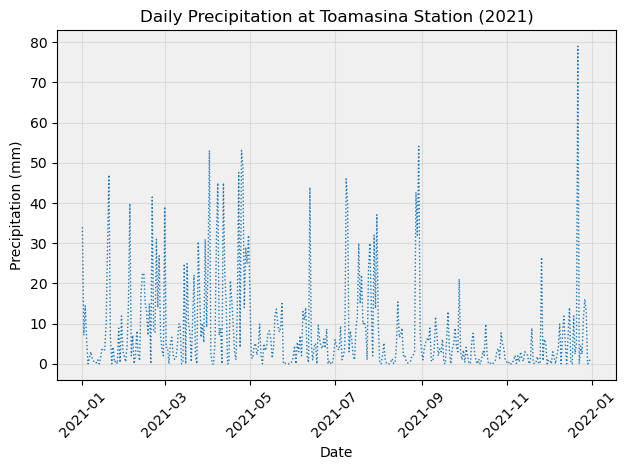

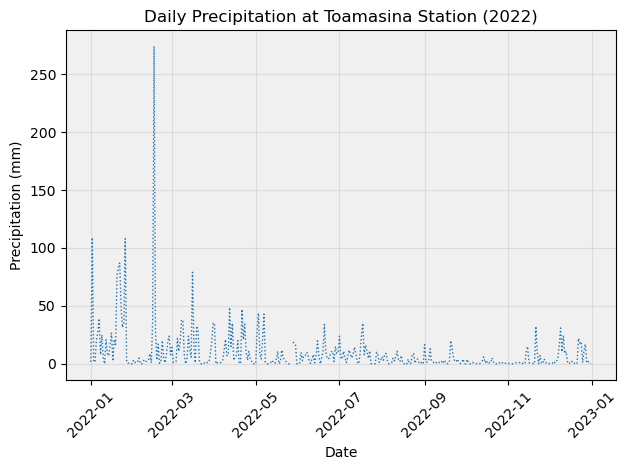

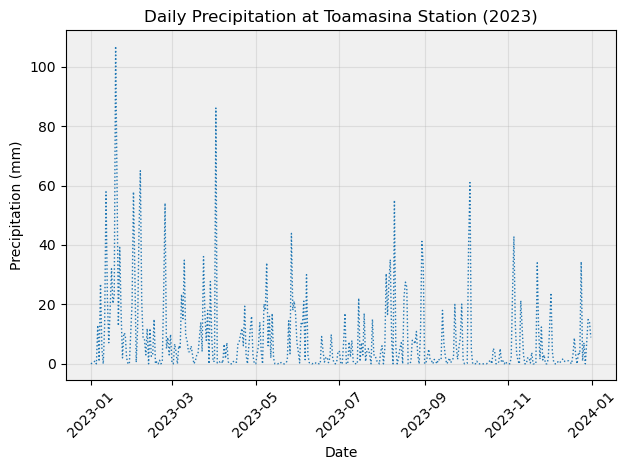

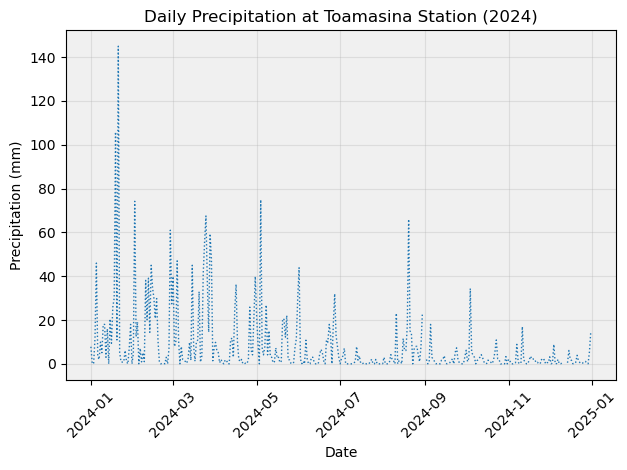

In [7]:
# Plot daily precipitation for Toamasina station by year
plt.figure()
for year in range(2021, 2025):
    df_year = toamasina[toamasina['date'].dt.year == year]
    plt.plot(df_year['date'], df_year['prcp'], linestyle=':', linewidth=1, label=str(year))
    plt.title(f'Daily Precipitation at Toamasina Station ({year})')
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(data_dir + f'daily_precipitation_toamasina_{year}.png', dpi=300)
    plt.show()

## 2. Load MSWEP grid-point data

In [8]:
daily_data = []
for year in range(2021, 2025):
    for month in range(1, 13):
        month_data = xr.load_dataset(MSWEP_dir + f"precip_daily_{year}{month:02d}_Madagascar_res_ERA5-Land.nc")
        month_data = month_data.sel(lat=pos_toamasina[0], lon=pos_toamasina[1], method='nearest')
        daily_data.append(month_data)

toamasina_MSWEP = xr.concat(daily_data, dim='time')


# toamasina_MSWEP = data_MSWEP.sel(lat=pos_toamasina[0], lon=pos_toamasina[1], method='nearest')
# toamasina_MSWEP_2021_2024 = toamasina_MSWEP.sel(time=slice('2021-01-01', '2024-12-31'))
# toamasina_MSWEP_2014_2020 = toamasina_MSWEP.sel(time=slice('2014-01-01', '2020-12-31'))
# climatology_MSWEP = toamasina_MSWEP_2014_2020.groupby('time.month').mean('time')


## 3. Comparison of time series

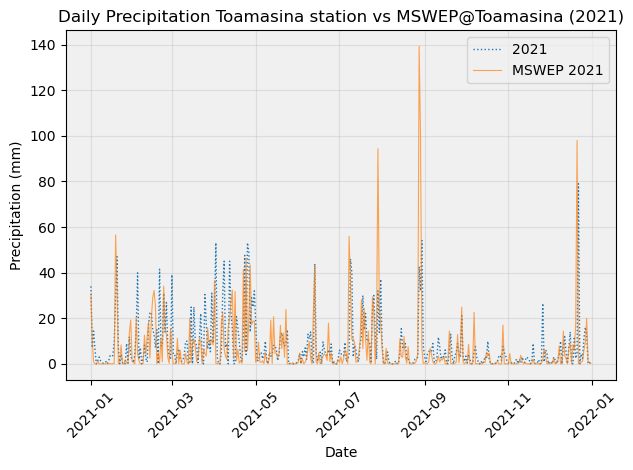

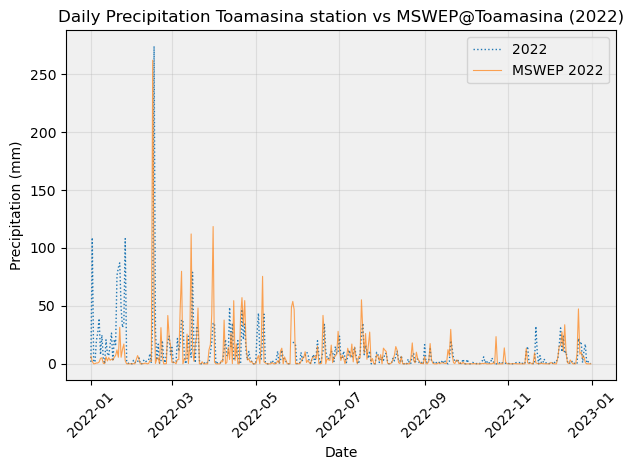

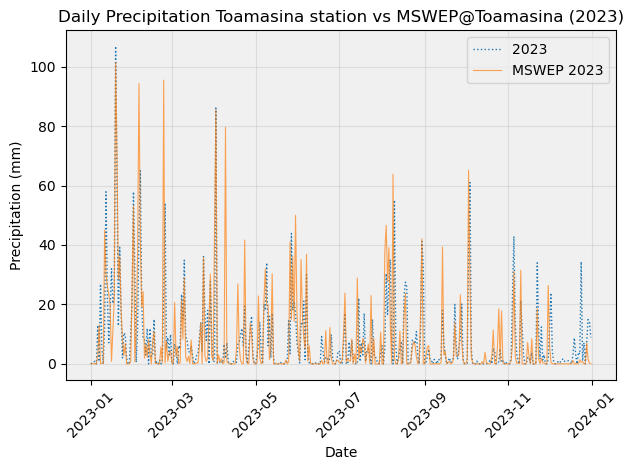

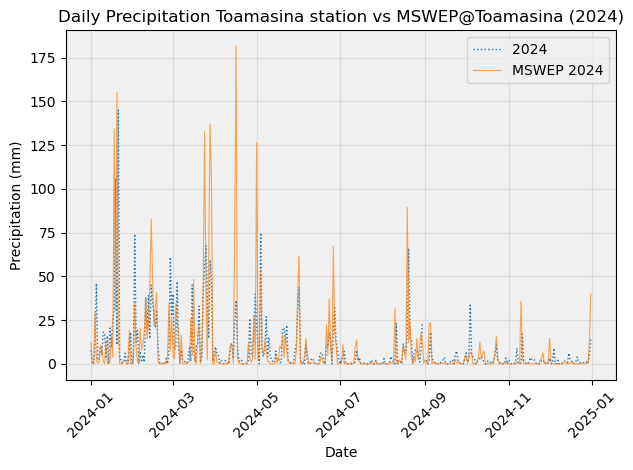

In [10]:
# Plot daily precipitation for Toamasina station by year
plt.figure()
for year in range(2021, 2025):
    df_year_toamasina = toamasina[toamasina['date'].dt.year == year]
    toamasina_MSWEP_year = toamasina_MSWEP.sel(time=slice(f'{year}-01-01', f'{year}-12-31'))
    plt.plot(df_year_toamasina['date'], df_year_toamasina['prcp'], linestyle=':', linewidth=1, label=str(year))
    plt.plot(toamasina_MSWEP_year['time'], toamasina_MSWEP_year['precipitation'], linestyle='-', linewidth=.8, alpha=0.7, label=f'MSWEP {year}')
    plt.title(f'Daily Precipitation Toamasina station vs MSWEP@Toamasina ({year})')
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir + f'daily_precipitation_{year}_toamasina_MSWEP.png', dpi=300)
    plt.show()

# Temperature

In [16]:
# Directories for data and output
data_dir = "/home/alice/Desktop/UniBo/data/obs_tamatave/"
ERA_dir = "/home/alice/Desktop/UniBo/data/ERA5-Land/t2m/daily/"
figure_dir = "/home/alice/Desktop/UniBo/figures/obs_tamatave/"

In [17]:
pos_toamasina = (-18.1, 49.3)  # Latitude, Longitude


## 1. Load and Inspect Toamasina Data

In [12]:
# Read all sheets
all_sheets = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx', sheet_name=None)

# Merge all years into one dataframe
dfs = []
for year, df_year in all_sheets.items():
    df_year['year'] = int(year)
    if int(year) >=2021:
        dfs.append(df_year[['date','tmin', 'tmax']])

toamasina = pd.concat(dfs, ignore_index=True)
# Check date in datetime format
toamasina['date'] = pd.to_datetime(toamasina['date'], errors='coerce')

print(f"Shape: {toamasina.shape}")
print(f"Columns: {list(toamasina.columns)}")
print(f"Dates: {toamasina['date'].min()} to {toamasina['date'].max()}")

Shape: (1461, 3)
Columns: ['date', 'tmin', 'tmax']
Dates: 2021-01-01 00:00:00 to 2024-12-31 00:00:00


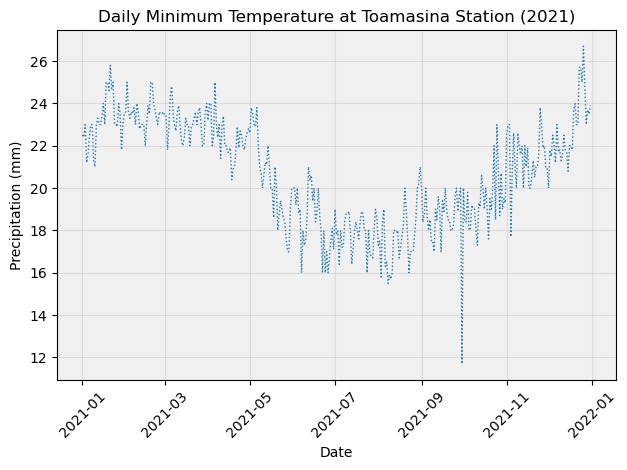

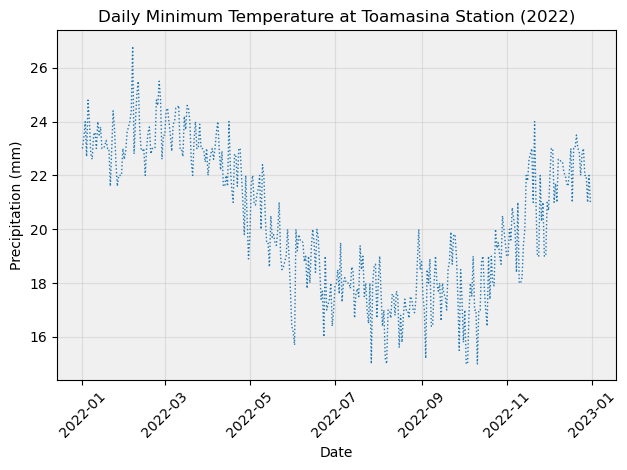

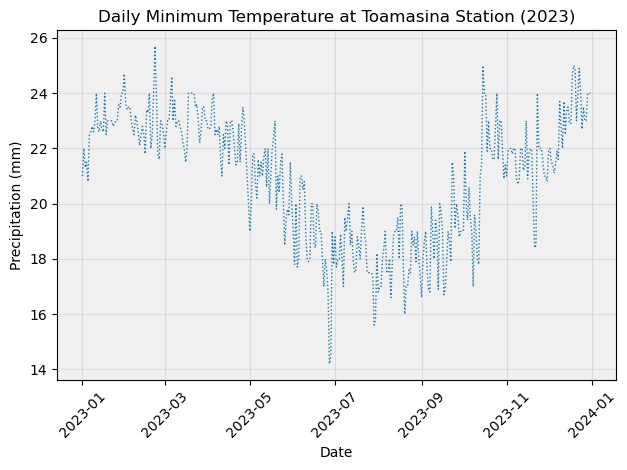

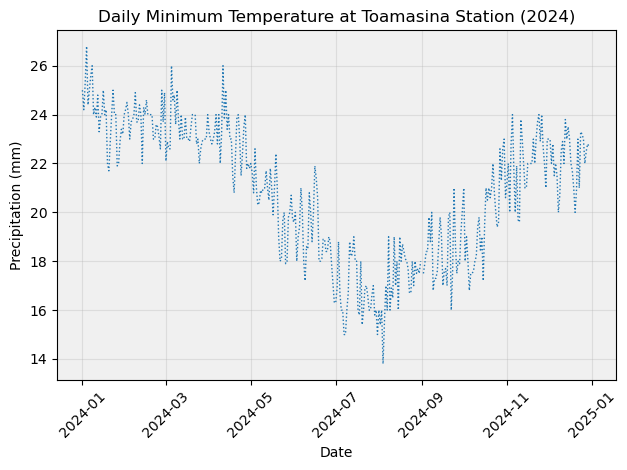

In [ ]:
# Plot daily precipitation for Toamasina station by year
plt.figure()
for year in range(2021, 2025):
    df_year = toamasina[toamasina['date'].dt.year == year]
    plt.plot(df_year['date'], df_year['tmin'], linestyle=':', linewidth=1, label=str(year))
    plt.title(f'Daily Minimum Temperature at Toamasina Station ({year})')
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(data_dir + f'daily_tmin_toamasina_{year}.png', dpi=300)
    plt.show()

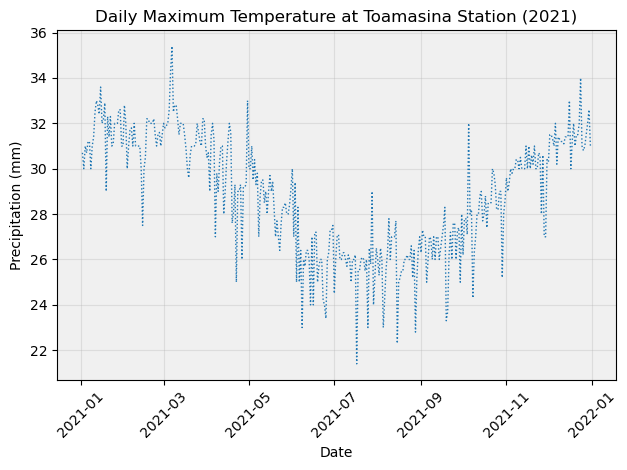

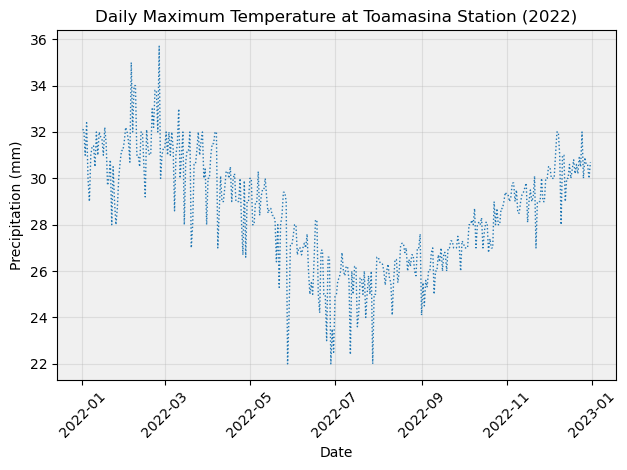

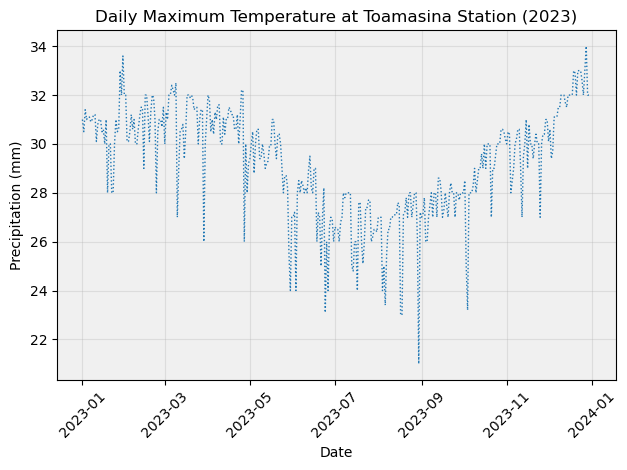

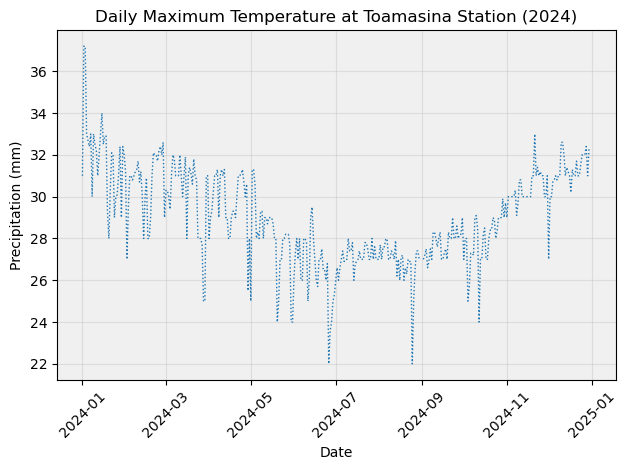

In [14]:
# Plot daily precipitation for Toamasina station by year
plt.figure()
for year in range(2021, 2025):
    df_year = toamasina[toamasina['date'].dt.year == year]
    plt.plot(df_year['date'], df_year['tmax'], linestyle=':', linewidth=1, label=str(year))
    plt.title(f'Daily Maximum Temperature at Toamasina Station ({year})')
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(data_dir + f'daily_tmax_toamasina_{year}.png', dpi=300)
    plt.show()

## 2. Load ERA5-Land grid-point data

In [19]:
daily_tmin_data = []
daily_tmax_data = []
for year in range(2021, 2025):
    tmin_data = xr.load_dataset(ERA_dir + f"{year}/t2m_daily_minimum_{year}.nc")
    tmin_data = tmin_data.sel(latitude=pos_toamasina[0], longitude=pos_toamasina[1], method='nearest')
    daily_tmin_data.append(tmin_data)
    tmax_data = xr.load_dataset(ERA_dir + f"{year}/t2m_daily_maximum_{year}.nc")
    tmax_data = tmax_data.sel(latitude=pos_toamasina[0], longitude=pos_toamasina[1], method='nearest')
    daily_tmax_data.append(tmax_data)

toamasina_tmin_ERA = xr.concat(daily_tmin_data, dim='valid_time')
toamasina_tmax_ERA = xr.concat(daily_tmax_data, dim='valid_time')

## 3. Comparison of time series

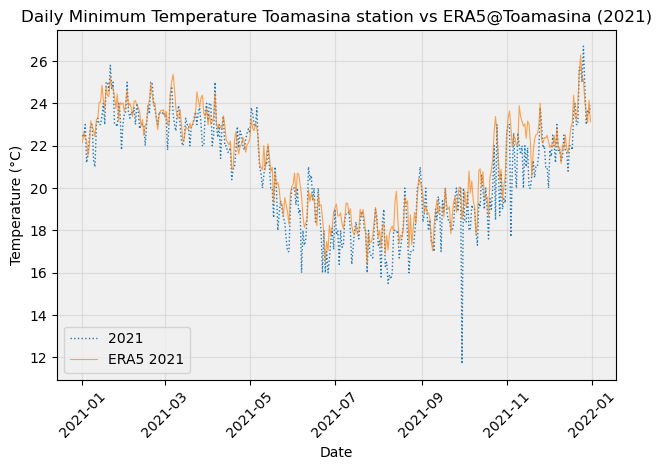

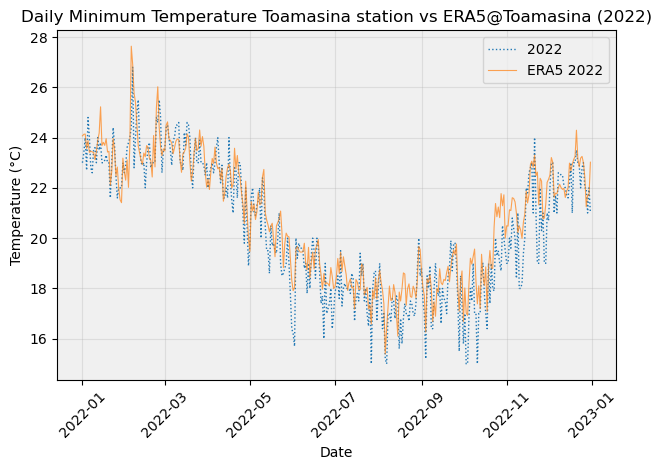

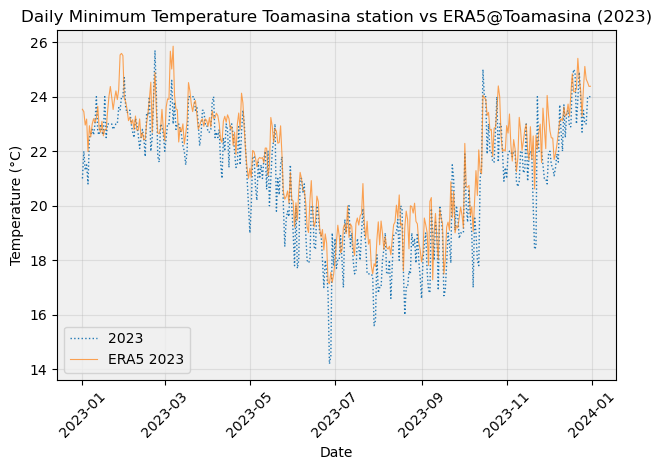

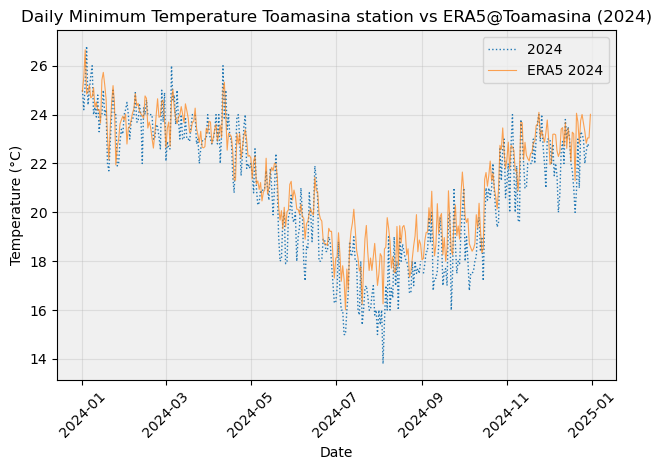

In [22]:
# Plot daily precipitemperature for Toamasina station by year
plt.figure()
for year in range(2021, 2025):
    df_year_toamasina = toamasina[toamasina['date'].dt.year == year]
    toamasina_ERA_year = toamasina_tmin_ERA.sel(valid_time=slice(f'{year}-01-01', f'{year}-12-31'))
    plt.plot(df_year_toamasina['date'], df_year_toamasina['tmin'], linestyle=':', linewidth=1, label=str(year))
    plt.plot(toamasina_ERA_year['valid_time'], toamasina_ERA_year['t2m']-273.15, linestyle='-', linewidth=.8, alpha=0.7, label=f'ERA5 {year}')
    plt.title(f'Daily Minimum Temperature Toamasina station vs ERA5@Toamasina ({year})')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir + f'daily_tmin_{year}_toamasina_ERA5.png', dpi=300)
    plt.show()

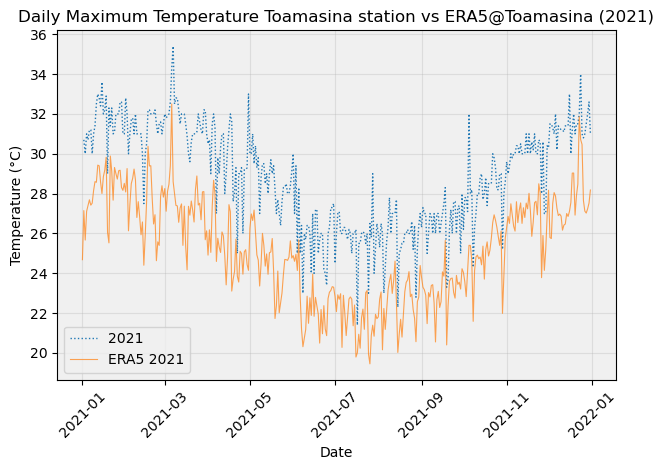

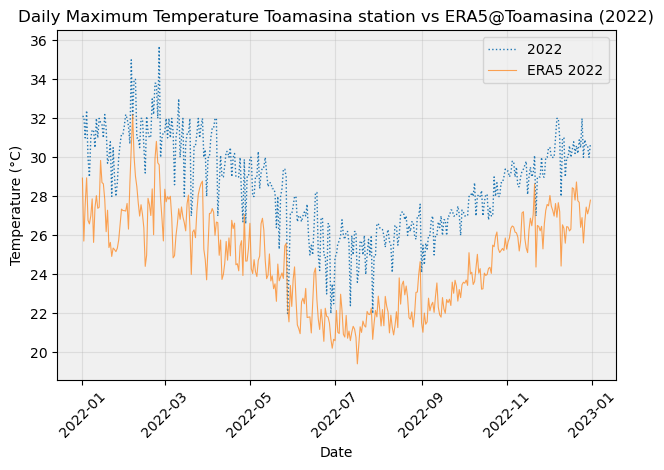

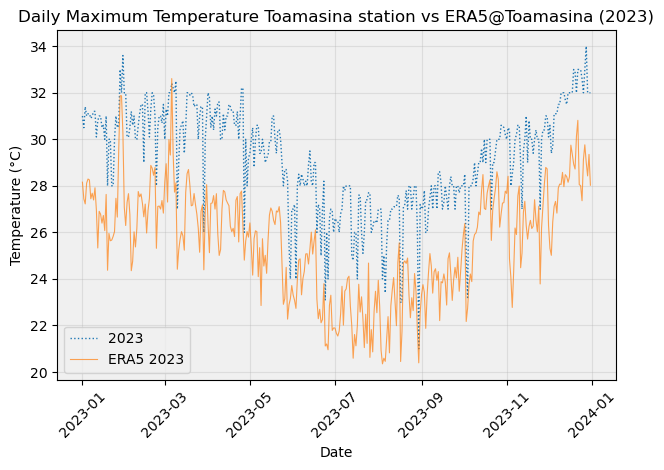

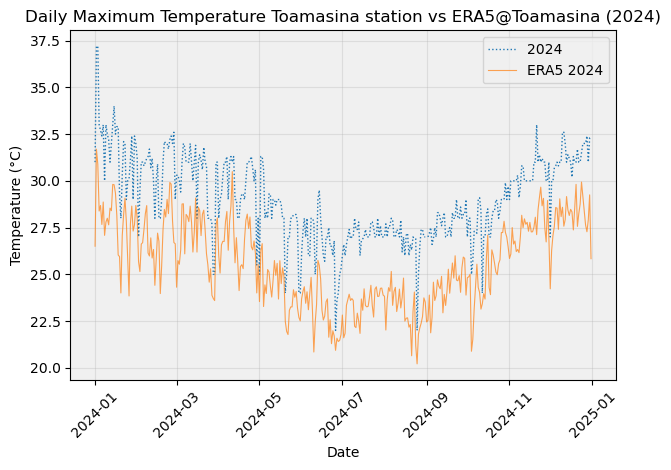

In [23]:
# Plot daily precipitemperature for Toamasina station by year
plt.figure()
for year in range(2021, 2025):
    df_year_toamasina = toamasina[toamasina['date'].dt.year == year]
    toamasina_ERA_year = toamasina_tmax_ERA.sel(valid_time=slice(f'{year}-01-01', f'{year}-12-31'))
    plt.plot(df_year_toamasina['date'], df_year_toamasina['tmax'], linestyle=':', linewidth=1, label=str(year))
    plt.plot(toamasina_ERA_year['valid_time'], toamasina_ERA_year['t2m']-273.15, linestyle='-', linewidth=.8, alpha=0.7, label=f'ERA5 {year}')
    plt.title(f'Daily Maximum Temperature Toamasina station vs ERA5@Toamasina ({year})')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(figure_dir + f'daily_tmax_{year}_toamasina_ERA5.png', dpi=300)
    plt.show()